# GDL - Midterm n.2

In the second midterm assignment, you are required to implement the layers of a **Convolutional Neural Network (CNN)** using **only NumPy**. You will test your implementation using pre-trained parameters, which are provided in a `zip` file that you should extract in the `params/` folder.

You are **not** allowed to use JAX, PyTorch, TensorFlow, or any other ML framework.

**Summary.** Overall, you are required to implement the following functions:
1. **`conv2d`**. 2D convolution
3. **`max_pool`**. Max-pooling.
4. **`avg_pool`**. Average-pooling.
5. **`relu`**. ReLU activation function.
6. **`cnn_forward`**. Implements the CNN architecture described in the provided docstring.

**Evaluation.** You can test your implementation by loading the provided parameters and evaluating on four selected samples. We will check your implementation with further hidden tests.

**Do not alter Sections 1 and 3 of the notebook**, instead **work only in Section 2**.

⚠️ **Fill the following cell with your student ID (matricola) and submission ID** ⚠️

In [17]:
# your student "matricola" goes here
student_id = 727099
# the ID from the sheet circulated in classroom goes here
submission_id = 50

assert student_id is not None and submission_id is not None, "Fill the student_id and submission_id before submitting!"

### 1. Libraries and Data Loading

Run these cells to download MNIST and load parameters in the `params` dictionary. You should place all the provided `npy` files in the `params/` directory.

In [18]:
import os
import struct
import gzip
import hashlib
import urllib.request
import numpy as np

In [19]:
# Download MNIST

MNIST_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
MNIST_TEST_FILES = {
    "test_images": ("t10k-images-idx3-ubyte.gz", "8d422c7b0a1c1c79245a5bcf07fe86e33eeafee792b84584aec276f5a2dbc4e6"),
    "test_labels": ("t10k-labels-idx1-ubyte.gz", "f7ae60f92e00ec6debd23a6088c31dbd2371eca3ffa0defaefb259924204aec6"),
}
DATA_DIR = "mnist_data"

def _download_file(filename: str, expected_sha256: str) -> str:
    os.makedirs(DATA_DIR, exist_ok=True)
    filepath = os.path.join(DATA_DIR, filename)
    if os.path.exists(filepath):
        sha = hashlib.sha256(open(filepath, "rb").read()).hexdigest()
        if sha == expected_sha256:
            return filepath
        print(f"Hash mismatch for {filename}, re-downloading …")

    url = MNIST_URL + filename
    print(f"Downloading {url} …")
    urllib.request.urlretrieve(url, filepath)

    sha = hashlib.sha256(open(filepath, "rb").read()).hexdigest()
    if sha != expected_sha256:
        raise RuntimeError(
            f"SHA-256 mismatch for {filename}: expected {expected_sha256}, got {sha}"
        )
    return filepath

def _parse_images(filepath: str) -> np.ndarray:
    """Parse IDX image file -> (N, 1, 28, 28) float32 in [0, 1]."""
    with gzip.open(filepath, "rb") as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(num, 1, rows, cols).astype(np.float32) / 255.0

def _parse_labels(filepath: str) -> np.ndarray:
    """Parse IDX label file -> (N,) int32."""
    with gzip.open(filepath, "rb") as f:
        _, num = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.astype(np.int32)

def load_mnist_test():
    """Return (test_images, test_labels)."""
    paths = {k: _download_file(*v) for k, v in MNIST_TEST_FILES.items()}
    return _parse_images(paths["test_images"]), _parse_labels(paths["test_labels"])

test_images, test_labels = load_mnist_test()
print(f"\nTest set: {test_images.shape[0]} images, shape={test_images.shape}")


Test set: 10000 images, shape=(10000, 1, 28, 28)


In [20]:
# Load parameters

PARAM_NAMES = [
    "conv1_weight",
    "conv1_bias",
    "conv2_weight",
    "conv2_bias",
    "fc1_weight",
    "fc1_bias",
    "fc2_weight",
    "fc2_bias",
]
PARAMS_DIR = "params"


def load_params(params_dir: str) -> dict:
    """Load all .npy parameter files from params_dir into a dict."""
    params = {}
    print("Parameter\tShape")
    for name in PARAM_NAMES:
        filepath = os.path.join(params_dir, f"{name}.npy")
        if not os.path.exists(filepath):
            raise FileNotFoundError(
                f"Parameter file not found: {filepath}\n"
                "Make sure the params/ folder is in the working directory."
            )
        params[name] = np.load(filepath).astype(np.float32)
        print(f"{name}\t{params[name].shape}")
    return params

params = load_params(PARAMS_DIR)

Parameter	Shape
conv1_weight	(32, 1, 3, 3)
conv1_bias	(32,)
conv2_weight	(64, 32, 3, 3)
conv2_bias	(64,)
fc1_weight	(128, 1024)
fc1_bias	(128,)
fc2_weight	(10, 128)
fc2_bias	(10,)


### 2. CNN Implementation

Implement the five functions below using numpy only **WITHOUT USING `np.convolve`**. The implementation should highlight your understanding of the inner workings of a Convolutional Network, try to be expressive and avoid shortcuts!

The functions `conv2d`, `max_pool` and `avg_pool` must input and output batches in the `NCHW` format, where:
1. `N` is the number of samples,
2. `C` is the number of channels,
3. `H` is the height, and
4. `W` is the width.

In [21]:
def conv2d(x: np.ndarray, w: np.ndarray, b: np.ndarray,
            stride: int, padding: int) -> np.ndarray:
    """
    Bidimensional convolution from C_in input channels to C_out output channels.
    The convolution has kernel size (kH x kW) and arbitrary stride and padding.

    Shapes:
      - W: (C_out, C_in, kH, kW)
      - b: (C_out,)
    """
    #  input dimensions: N (batch size), C_in (input channels), H (height), W (width)
    N, C_in, H, W = x.shape
    #  kernel dimensions: C_out (output channels), _, kH (kernel height), kW (kernel width)
    C_out, _, kH, kW = w.shape

    # Calculating output 
    H_out = (H - kH + 2 * padding) // stride + 1
    W_out = (W - kW + 2 * padding) // stride + 1

    #pading the input image
    x_padded = np.pad(x, ((0, 0), (0, 0), (padding, padding), (padding, padding)), mode='constant')


    output = np.zeros((N, C_out, H_out, W_out), dtype=x.dtype)

    for n in range(N): 
        for c_out in range(C_out):  
            for h_out in range(H_out):  
                for w_out in range(W_out):  
                    #defining the receptive field (slice of the input image)
                    h_start = h_out * stride
                    h_end = h_start + kH
                    w_start = w_out * stride
                    w_end = w_start + kW

                    #extracting the slice from the padded input
                    x_slice = x_padded[n, :, h_start:h_end, w_start:w_end]

                    #element-wise multiplication and sum for each input channel
                    convolution_sum = np.sum(x_slice * w[c_out, :, :, :])

                    #adding bias and store in output
                    output[n, c_out, h_out, w_out] = convolution_sum + b[c_out]

    return output

In [22]:
def max_pool(x: np.ndarray, pool_size: int = 2, stride: int = 2,) -> np.ndarray:
    """
    Max-pooling with arbitrary pool size and stride.
    """
    N, C, H, W = x.shape

    #calculating output dimensions
    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    output = np.zeros((N, C, H_out, W_out), dtype=x.dtype)

    for n in range(N):   
        for c in range(C):  
            for h_out in range(H_out):  
                for w_out in range(W_out):  
                    #defining the receptive field
                    h_start = h_out * stride
                    h_end = h_start + pool_size
                    w_start = w_out * stride
                    w_end = w_start + pool_size

                    #extracting the slice and finding the maximum value
                    output[n, c, h_out, w_out] = np.max(x[n, c, h_start:h_end, w_start:w_end])

    return output

In [23]:
def avg_pool(x: np.ndarray, pool_size: int = 2, stride: int = 2) -> np.ndarray:
    """
    Average-pooling with arbitrary pool size and stride.
    """
    N, C, H, W = x.shape

    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    output = np.zeros((N, C, H_out, W_out), dtype=x.dtype)

    #performing average pooling
    for n in range(N): 
        for c in range(C): 
            for h_out in range(H_out): 
                for w_out in range(W_out): 
                    #defining the receptive field
                    h_start = h_out * stride
                    h_end = h_start + pool_size
                    w_start = w_out * stride
                    w_end = w_start + pool_size

                    output[n, c, h_out, w_out] = np.mean(x[n, c, h_start:h_end, w_start:w_end])

    return output

In [24]:
def relu(x: np.ndarray) -> np.ndarray:
    """
    Rectified Linear Unit activation.
    """
    return np.maximum(0, x)

In [25]:
def cnn_forward(params: dict, x: np.ndarray) -> np.ndarray:
    """
    Forward pass of the CNN using pure NumPy.
    The architecture is:
        Conv1 (1->32, 3x3 kernel, stride=2, padding=1) -> ReLU -> AvgPool(2x2, stride=2)
        Conv2 (32->64, 3x3 kernel, stride=1, padding=2) -> ReLU -> MaxPool(2x2, stride=2)
        Flatten
        FC1 (1024->128) -> ReLU
        FC2 (128->10)
    """
    # Layer 1: Conv1 -> ReLU -> AvgPool
    # Conv1: 1->32, 3x3 kernel, stride=2, padding=1
    x = conv2d(x, params["conv1_weight"], params["conv1_bias"], stride=2, padding=1)
    x = relu(x)
    x = avg_pool(x, pool_size=2, stride=2)

    # Layer 2: Conv2 -> ReLU -> MaxPool
    # Conv2: 32->64, 3x3 kernel, stride=1, padding=2
    x = conv2d(x, params["conv2_weight"], params["conv2_bias"], stride=1, padding=2)
    x = relu(x)
    x = max_pool(x, pool_size=2, stride=2)

    # Flatten: (N, C, H, W) -> (N, C*H*W)
    N_batch, C_final, H_final, W_final = x.shape
    x = x.reshape(N_batch, C_final * H_final * W_final)

    # Layer 3: FC1 -> ReLU
    # FC1: (1024->128)
    x = np.dot(x, params["fc1_weight"].T) + params["fc1_bias"]
    x = relu(x)

    # Layer 4: FC2
    # FC2: (128->10)
    x = np.dot(x, params["fc2_weight"].T) + params["fc2_bias"]

    return x

### 3. Evaluation

This section evaluates your implementation on the MNIST test set using the pre-trained parameters. On the following images, a correct implementation correctly classifies the first two images and misclassifies the second two.

**Do not alter this section.**

In [26]:
indices = np.array([0, 1, 78, 320])
sample_images = test_images[indices]
sample_labels = test_labels[indices]

# Perform forward pass
logits = cnn_forward(params, sample_images)
predictions = np.argmax(logits, axis=-1)

for i in range(4):
    print(f"Index {i} | GT={sample_labels[i]} | cnn(x)={predictions[i]}")

Index 0 | GT=7 | cnn(x)=7
Index 1 | GT=2 | cnn(x)=2
Index 2 | GT=9 | cnn(x)=8
Index 3 | GT=9 | cnn(x)=8


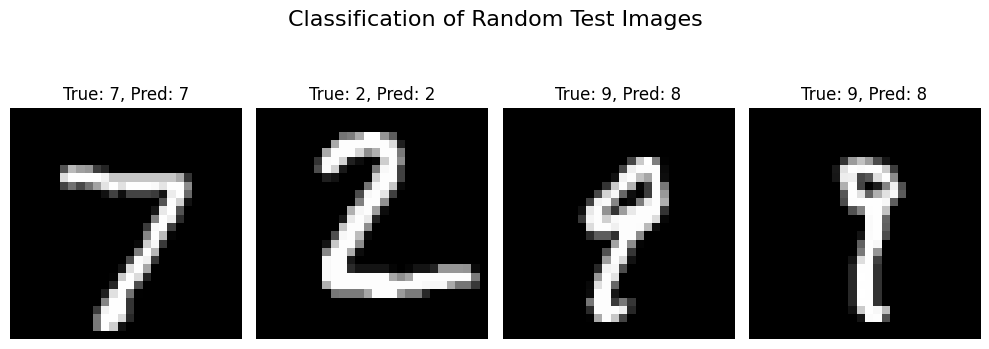

In [27]:
import matplotlib.pyplot as plt

# Display the images and their classifications
plt.figure(figsize=(10, 4))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {sample_labels[i]}, Pred: {predictions[i]}")
    plt.axis('off')
plt.suptitle('Classification of Random Test Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()